# Laboratorio 1 – Exploración, preparación y regresión lineal

**Curso:** ISIS2611

**Caso:** AlpesHearth

**Integrantes:**
- Nikol Katherin Rodriguez Ortiz - 202317538
- Daniel Bolivar Bernal - 202310329

---

## 1. Exploración de los datos
En esta sección se realiza una exploración inicial del conjunto de datos con el fin de entender su estructura, detectar valores faltantes, duplicados y posibles problemas de calidad.

In [234]:
import pandas as pd
import numpy as np
import seaborn as sns


train = pd.read_csv('Datos Lab 1.csv')
train_df = train.copy()
train_df.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


In [235]:
# Carga del diccionario de datos
dicc_pacientes = pd.read_excel('DiccPacientes.xlsx')
dicc_pacientes

,Nombre Columna,Tipo de dato,Comentarios
0,Patient ID,String,Identificador del paciente
1,Date of Service,Date,Fecha de la atención
2,Sex,String,"Sexo (Femenino, Masculino)"
3,Age,Integer,Edad
4,Weight (kg),Float,Peso
5,Height (m),Float,Altura
6,BMI,Float,Índice de masa corporal
7,Abdominal Circumference (cm),Float,Circunferencia abdominal
8,Blood Pressure (mmHg),String,"Presión sanguínea, de la forma ""<Presión arter..."
9,Total Cholesterol (mg/dL),Float,Colesterol total


In [236]:
# Información general del dataset
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   object 
 1   Date of Service               1639 non-null   object 
 2   Sex                           1639 non-null   object 
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   object 
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smoking Status                1639 non-null   object 
 13  Dia

In [237]:
# Estadísticas descriptivas
train_df.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1571.000000,1557.000000,1585.000000,1571.000000,1563.000000,1578.000000,1554.000000,1582.000000,1610.000000
mean,46.803186,85.666006,1.757439,28.424744,91.538861,199.043673,56.183558,117.836860,175.770082,0.522440,125.632637,82.887536,113.235896,18.227281
std,13.039479,21.712504,0.118012,7.309275,13.427985,59.388670,16.721702,32.379634,11.695880,0.085692,22.577463,15.503625,61.435291,10.767666
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000
25%,37.000000,67.100000,1.666500,22.600000,79.700000,150.000000,42.000000,92.000000,167.000000,0.453000,108.000000,71.000000,62.000000,15.150000
50%,46.000000,86.314000,1.760000,28.000000,91.200000,199.000000,56.000000,115.000000,176.000000,0.519000,125.000000,82.000000,112.000000,16.967000
75%,55.000000,104.801500,1.850000,33.963000,102.267250,250.000000,70.000000,139.000000,185.000000,0.582000,141.000000,93.000000,159.000000,18.900000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000


In [238]:
# #  Instalaciones para el análisis exploratorio de datos
# %pip install ydata-profiling
# %pip show ydata-profiling
# from ydata_profiling import ProfileReport
# profile = ProfileReport(
#     train_df,
#     title="Reporte de Análisis Exploratorio",
#     explorative=True
# )

# profile.to_notebook_iframe()


### Alertas Detectadas en el Análisis Exploratorio

Durante el análisis exploratorio del dataset se identificaron múltiples alertas relacionadas con duplicados, correlaciones altas entre variables y valores faltantes. A continuación, se describen detalladamente los hallazgos y su impacto en el proceso de limpieza de datos.



#### 1. Filas Duplicadas

Se detectaron **151 filas duplicadas**, lo que corresponde al **9.2% del dataset**.

La presencia de duplicados puede generar varios problemas:
- Sesgos en análisis estadísticos.
- Sobreestimación de patrones.
- Impacto negativo en modelos predictivos.

**Decisión tomada:**  
Eliminar los duplicados para evitar redundancias y garantizar que cada registro represente una observación única.



#### 2. Altas Correlaciones entre Variables

Se identificaron múltiples pares de variables con correlaciones altas. Esto puede indicar:
- Redundancia de información.
- Posible multicolinealidad en modelos de machine learning.

##### Casos relevantes:

- **Altura en metros vs altura en centímetros**
  - `Height (m)` y `Height (cm)` contienen la misma información en distintas unidades.
  - **Decisión:** Mantener solo una representación (preferiblemente cm por legibilidad).

- **Circunferencia abdominal vs Waist-to-Height Ratio**
  - El ratio depende directamente de medidas físicas, por lo que la correlación es esperada.
  - **Decisión:** Mantener ambas si el ratio aporta valor clínico.

- **Colesterol total vs LDL estimado**
  - Alta correlación debido a su relación biomédica directa.
  - **Decisión:** Evaluar eliminar una variable si se requiere reducir dimensionalidad.

- **BMI con peso y riesgo cardiovascular**
  - El BMI es una variable derivada del peso y la altura, por lo que su correlación es lógica.
  - **Decisión:** Mantenerla por su relevancia clínica y uso estándar.

En general, las correlaciones fueron evaluadas considerando el contexto médico antes de eliminar variables.



#### 3. Valores Faltantes (Missing Values)

Se detectaron valores faltantes en múltiples variables, con porcentajes entre **1.8% y 5.2%**.

##### Variables con más datos faltantes:
- Diastolic BP (5.2%)
- HDL (5.0%)
- Waist-to-Height Ratio (4.6%)
- Weight (4.5%)

##### Variables con menor proporción:
- CVD Risk Score (1.8%)
- BMI (3.2%)
- Fasting Blood Sugar (3.3%)

Aunque ningún atributo supera el 10% de valores faltantes, la distribución es amplia en casi todas las columnas, lo que sugiere problemas en la recolección de datos.

**Decisión tomada:**
- No eliminar columnas completas, ya que el porcentaje de pérdida es moderado.
- Aplicar imputación dependiendo del tipo de variable:
  - Media o mediana para variables numéricas continuas.
  - Métodos derivados cuando la variable es calculable (ej. BMI).



#### 4. Impacto en la Calidad del Dataset

Los hallazgos indican que el dataset presenta problemas comunes en datos reales:

- Redundancia estructural (variables altamente correlacionadas).
- Inconsistencias por duplicación de registros.
- Valores faltantes distribuidos en múltiples atributos.

Sin embargo, la mayoría de los problemas son **corregibles mediante técnicas estándar de limpieza**, lo que hace viable su uso para análisis posteriores.



#### 5. Conclusión

El análisis de alertas permitió identificar los principales problemas de calidad en el dataset. Las decisiones tomadas priorizan:

- Preservar la mayor cantidad de información posible.
- Reducir redundancias innecesarias.
- Mantener variables clínicamente relevantes.
- Garantizar consistencia en el análisis posterior.

Estas acciones forman la base para una fase sólida de limpieza y transformación de datos, asegurando que el dataset esté en condiciones adecuadas para modelado y análisis estadístico.
    


## 2. Preparación de los datos
En esta sección se describen y justifican las decisiones de limpieza, transformación y selección de variables realizadas antes de entrenar los modelos.

### 2.1 Unicidad

En esta parte hacemos una verificación de valores duplicados.

In [239]:

train_df.duplicated().sum()

151

#### 2.1.1 Identificador único de pacientes

Se verificó que la columna Patient ID tuviera valores únicos para evitar duplicidad de registros.

**Justificación**

El identificador de paciente debe ser único en cualquier dataset clínico. La duplicación podría generar sesgos en el análisis, especialmente en métricas poblacionales o modelos predictivos.

No se realizaron modificaciones ya que los IDs eran únicos.

In [240]:


dup_counts = (train_df[["Patient ID"]].groupby('Patient ID').size().reset_index(name='Count').sort_values(by='Count', ascending=False))

dup_counts= dup_counts[dup_counts['Count']>1]

for id_, n in dup_counts[["Patient ID","Count"]].values:
    print(f"Id={id_} → {n} apariciones")


Id=bCoz6266 → 3 apariciones
Id=QJtE0701 → 3 apariciones
Id=NIUR3991 → 3 apariciones
Id=NOcd2332 → 3 apariciones
Id=DxSq2036 → 3 apariciones
Id=pEpZ9034 → 3 apariciones
Id=NvOx6625 → 3 apariciones
Id=oSqq7069 → 3 apariciones
Id=xFVW5778 → 3 apariciones
Id=DhUJ7239 → 3 apariciones
Id=nmgP2712 → 3 apariciones
Id=PHii0023 → 3 apariciones
Id=QAxZ5540 → 3 apariciones
Id=mrZW4662 → 3 apariciones
Id=DIVT3121 → 3 apariciones
Id=CKKa5109 → 3 apariciones
Id=miQs7675 → 3 apariciones
Id=mMoS9467 → 3 apariciones
Id=ltOL4864 → 3 apariciones
Id=lqUc7918 → 3 apariciones
Id=ChGR7779 → 3 apariciones
Id=RlsB8509 → 3 apariciones
Id=RwGu5647 → 3 apariciones
Id=CYeS2965 → 3 apariciones
Id=kijK0146 → 3 apariciones
Id=STpP5810 → 3 apariciones
Id=kajW6905 → 3 apariciones
Id=THSJ8564 → 3 apariciones
Id=NGwd5164 → 3 apariciones
Id=wWyM6139 → 3 apariciones
Id=LpyK7269 → 3 apariciones
Id=LdMm6225 → 3 apariciones
Id=GhAN9460 → 3 apariciones
Id=vKKa9024 → 3 apariciones
Id=HNpy8362 → 3 apariciones
Id=HNwp6592 → 3 apar

In [241]:
# Obtener IDs que están repetidos
ids_repetidos = train_df['Patient ID'][train_df.duplicated('Patient ID', keep=False)]

# Mostrar TODAS las filas y TODAS las columnas de esos IDs
train_df.loc[train_df['Patient ID'].isin(ids_repetidos)].sort_values('Patient ID')



,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
17,AhYt1346,09-28-2020,M,41.0,71.300,1.730,23.800,107.900,139/61,253.0,...,Low,Y,173.000,NaN,139.0,NaN,Hypertension Stage 1,146.0,16.770,HIGH
1584,AhYt1346,09-28-2020,M,41.0,71.300,1.730,23.800,107.900,139/61,253.0,...,Low,Y,173.000,NaN,139.0,NaN,Hypertension Stage 1,146.0,16.770,HIGH
1227,AhYt1346,09-28-2020,M,41.0,71.300,1.730,23.800,107.900,139/61,253.0,...,Low,Y,173.000,NaN,139.0,NaN,Hypertension Stage 1,146.0,-13.090,HIGH
1117,Axab9332,2021-12-11,F,58.0,69.870,1.944,20.785,86.259,162/106,151.0,...,Moderate,N,194.450,0.444,162.0,106.0,Hypertension Stage 2,44.0,23.430,HIGH
383,Axab9332,2021-12-11,F,58.0,69.870,1.944,20.785,86.259,162/106,151.0,...,Moderate,N,194.450,0.444,162.0,106.0,Hypertension Stage 2,44.0,15.277,HIGH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,zhZi8857,"December 05, 2025",F,36.0,81.200,1.750,26.500,74.000,141/76,225.0,...,Moderate,Y,175.000,0.423,141.0,NaN,Hypertension Stage 2,164.0,16.850,HIGH
727,zhZi8857,"December 05, 2025",F,36.0,81.200,1.750,26.500,74.000,141/76,225.0,...,Moderate,Y,175.000,0.423,141.0,NaN,Hypertension Stage 2,164.0,41.813,HIGH
1548,zhZi8857,"December 05, 2025",F,36.0,81.200,1.750,26.500,74.000,141/76,225.0,...,Moderate,Y,175.000,0.423,141.0,NaN,Hypertension Stage 2,164.0,16.850,HIGH
1565,zxhX5525,"November 13, 2021",M,26.0,58.953,1.688,25.286,NaN,110/114,258.0,...,High,Y,168.763,0.455,110.0,114.0,Hypertension Stage 2,170.0,15.717,HIGH


Como se observó anteriormente, las filas con IDs repetidos contienen exactamente la misma información en todas sus variables. Esto indica que se trata de duplicados completos y no de registros distintos con coincidencias parciales. Por esta razón, se tomó la decisión de eliminar todos los IDs repetidos, ya que no aportan información adicional al análisis y podrían sesgar los resultados estadísticos o los modelos posteriores.

In [242]:
# borrar los repetidos
train_df = train_df.drop_duplicates(subset='Patient ID', keep='first')


### 2.2. Validez de los datos

#### 2.2.1 Corrección de validez: Normalización del tipo de dato en la variable Edad

**Decisión tomada**: Durante el análisis de validez se identificó que la variable Age presentaba valores con decimales, lo cual no es coherente desde el punto de vista semántico, ya que la edad normalmente se expresa como un número entero en años en contextos clínicos y demográficos. La presencia de valores decimales puede deberse a errores de captura, transformaciones previas o cálculos automáticos.

Para corregir esta inconsistencia, se decidió redondear los valores al entero más cercano y posteriormente convertir explícitamente el tipo de dato a entero. Esta transformación permite mantener la coherencia lógica de la variable sin alterar significativamente su distribución, asegurando que los datos sean interpretables y válidos para análisis posteriores.

In [243]:
# Redondear edad al entero más cercano
train_df['Age'] = train_df['Age'].round()

# Droppeamos NaN
train_df = train_df.dropna(subset=['Age'])

# Convertir explícitamente a entero
train_df['Age'] = train_df['Age'].astype(int)


#### 2.2.2 Corrección de validez: Normalización del tipo de dato en la variable BMI

**Decisión tomada** : En el análisis de validez se identificó que la variable BMI contenía valores fuera de rangos fisiológicamente plausibles, específicamente un valor mínimo de 4.317 y valores cercanos a 53.028. Aunque el dataset puede incluir población infantil y casos de obesidad severa, un IMC de 4.317 resulta clínicamente inviable, ya que valores por debajo de 10 no son compatibles con condiciones reales de supervivencia humana y suelen indicar errores de medición o registro. Por otro lado, el valor máximo observado (53.028) sí puede corresponder a obesidad mórbida extrema, por lo que no se considera inválido.

Para garantizar la validez de los datos sin eliminar información útil, se optó por aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 10 y 80. Este enfoque permite conservar todos los registros, evitando pérdidas de información, mientras se corrigen valores claramente erróneos o producto de inconsistencias en la captura de datos. Además, esta técnica mantiene la distribución general de la variable sin introducir sesgos fuertes, a diferencia de eliminar registros o imputar valores artificiales.

In [244]:
train_df['BMI'] = train_df['BMI'].clip(lower=10, upper=80)

#### 2.2.3 Corrección de validez: Normalización del tipo de dato en la variable Total Cholesterol (mg/dL)

**Decisión tomada** : En el análisis de validez se identificó que la variable Total Cholesterol (mg/dL) presentaba valores fuera de rangos clínicamente plausibles, incluyendo valores negativos (como -1.256 mg/dL) y extremos elevados cercanos al límite superior observado en los datos. Un valor negativo de colesterol es fisiológicamente imposible, ya que esta medida representa una concentración en sangre y no puede ser menor a cero, lo que indica errores de captura o registro. Para corregir estas inconsistencias sin eliminar registros, se optó por aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 50 y 600 mg/dL. Este intervalo se eligió porque cubre desde niveles muy bajos clínicamente posibles hasta casos extremos de hipercolesterolemia, permitiendo mantener la variabilidad real del dataset mientras se eliminan valores inválidos. Esta decisión conserva la integridad de los datos y evita introducir sesgos derivados de la eliminación de registros o imputaciones artificiales.

In [245]:
train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].clip(lower=50, upper=600)

#### 2.2.4 Corrección de validez: Normalización del tipo de dato en la variable Total Cholesterol (mg/dL)

**Decisión tomada** : En el análisis de validez se observó que la variable HDL (mg/dL) presentaba valores fuera de rangos fisiológicamente plausibles, incluyendo valores extremadamente bajos cercanos a cero (como 0.008 mg/dL). Aunque el HDL puede variar entre individuos, valores cercanos a cero no son clínicamente realistas, ya que siempre existe una concentración mínima de lipoproteínas de alta densidad en sangre. Para corregir estas inconsistencias sin eliminar registros válidos, se aplicó una estrategia de recorte de valores (clipping), estableciendo un rango entre 10 y 150 mg/dL. Este intervalo abarca niveles muy bajos observables en poblaciones con alto riesgo cardiovascular hasta valores elevados presentes en individuos con perfiles lipídicos favorables. Esta decisión permite preservar la distribución general de los datos mientras se eliminan valores claramente erróneos, evitando introducir sesgos derivados de eliminaciones o imputaciones innecesarias.

In [246]:
train_df['HDL (mg/dL)'] = train_df['HDL (mg/dL)'].clip(lower=10, upper=150)

#### 2.2.5 Corrección de validez: Normalización del tipo de dato en la variable Fasting Blood Sugar (mg/dL)

**Decisión tomada** : En el análisis de validez se identificó que la variable Fasting Blood Sugar (mg/dL) presentaba valores fuera de rangos clínicamente plausibles, incluyendo niveles extremadamente bajos cercanos a 15 mg/dL. Aunque pueden existir valores bajos en casos de hipoglucemia, niveles por debajo de 40 mg/dL son considerados críticos y poco frecuentes en mediciones rutinarias, lo que sugiere posibles errores de captura o medición. Asimismo, se contempló la posibilidad de valores altos en pacientes con descontrol metabólico severo, por lo que se definió un rango amplio pero clínicamente razonable. Para garantizar la validez sin eliminar registros, se aplicó una estrategia de recorte (clipping) estableciendo límites entre 40 y 500 mg/dL. Este enfoque permite mantener la mayoría de observaciones reales, incluyendo casos extremos plausibles, mientras se eliminan valores claramente erróneos, preservando la distribución general de la variable sin introducir sesgos innecesarios.

In [247]:
train_df['Fasting Blood Sugar (mg/dL)'] = train_df['Fasting Blood Sugar (mg/dL)'].clip(lower=40, upper=500)

#### 2.2.6 Corrección de validez: Normalización del tipo de dato en la variable Waist-to-Height Ratio

**Decisión tomada** : En el análisis de validez se verificó la coherencia interna de la variable Waist-to-Height Ratio, ya que esta puede calcularse directamente a partir de dos variables existentes en el dataset: la circunferencia abdominal y la estatura en centímetros. Al recalcular el indicador y compararlo con el valor almacenado, se identificaron pequeñas diferencias atribuibles a errores de redondeo o precisión decimal. Para corregir estas inconsistencias sin alterar valores potencialmente válidos, se definió una tolerancia de 0.01. Cuando la diferencia entre el valor registrado y el recalculado se encontraba dentro de este margen, se reemplazó por el valor calculado, asegurando coherencia matemática entre variables relacionadas. Finalmente, se redondeó a tres decimales para mantener uniformidad en la precisión de la variable. Esta estrategia mejora la validez del dataset al garantizar consistencia entre indicadores derivados sin introducir sesgos ni eliminar información.


In [248]:

calculated_whr = (
    train_df['Abdominal Circumference (cm)'] /
    train_df['Height (cm)']
)


difference = (
    train_df['Waist-to-Height Ratio'] - calculated_whr
).abs()


tolerance = 0.01


match_mask = difference <= tolerance


train_df.loc[match_mask, 'Waist-to-Height Ratio'] = calculated_whr[match_mask]


train_df['Waist-to-Height Ratio'] = \
    train_df['Waist-to-Height Ratio'].round(3)


#### 2.2.7 Corrección de validez: Normalización del tipo de dato en la variable Systolic BP

**Decisión tomada** : En el análisis de validez se identificó que la variable Systolic BP contenía valores fuera de rangos fisiológicamente plausibles. En la tabla de métricas inicial se observaron valores extremos, como mínimos cercanos a 49 mmHg y máximos superiores a 200 mmHg, que pueden corresponder a errores de medición, digitación o inconsistencias en la captura de datos. Desde el punto de vista clínico, aunque la presión sistólica puede variar ampliamente según la condición del paciente, valores por debajo de 70 mmHg suelen asociarse a estados críticos poco frecuentes en mediciones rutinarias, mientras que valores superiores a 250 mmHg son extremadamente raros y generalmente corresponden a errores. Por esta razón, se optó por aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 70 y 250 mmHg. Esta decisión permite mantener todos los registros, evitando pérdida de información, mientras se corrigen valores claramente inválidos y se preserva la coherencia clínica de la variable sin introducir sesgos artificiales.

In [249]:
train_df['Systolic BP'] = train_df['Systolic BP'].clip(lower= 70, upper= 250)

#### 2.2.8 Corrección de validez: Normalización del tipo de dato en la variable Diastolic BP

**Decisión tomada** : En el análisis de validez se identificó que la variable Diastolic BP contenía valores fuera de rangos fisiológicamente plausibles. En la tabla de métricas inicial se observaron valores extremos que se alejaban de lo esperado en mediciones clínicas normales, lo cual puede estar asociado a errores de digitación, fallos en los dispositivos de medición o inconsistencias en la recolección de datos. Desde el punto de vista clínico, aunque la presión diastólica puede variar entre individuos, valores por debajo de 40 mmHg suelen indicar estados de hipotensión severa poco frecuentes en contextos poblacionales, mientras que valores superiores a 150 mmHg corresponden a crisis hipertensivas graves y extremadamente raras en estudios generales, por lo que es más probable que representen errores. Por esta razón, se optó por aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 40 y 150 mmHg. Esta decisión permite conservar todos los registros sin eliminarlos, corrigiendo valores claramente inválidos y manteniendo la coherencia clínica de la variable sin introducir distorsiones significativas en el análisis.

In [250]:
train_df['Diastolic BP'] = train_df['Diastolic BP'].clip(lower= 40, upper= 150)

#### 2.2.9 Corrección de validez: Normalización del tipo de dato en la variable Estimated LDL (mg/dL)

**Decisión tomada** : En el análisis de validez se identificó que la variable Estimated LDL (mg/dL) presentaba valores fuera de rangos clínicamente plausibles. En la tabla de métricas inicial se observaron valores mínimos y máximos que se alejaban de los niveles esperados para el colesterol LDL en población general, lo cual puede atribuirse a errores de medición, digitación o inconsistencias en la estimación del valor. Desde el punto de vista clínico, aunque el LDL puede variar dependiendo del perfil metabólico del paciente, valores por debajo de 90 mg/dL son poco comunes cuando se trata de estimaciones poblacionales sin intervención farmacológica, mientras que valores superiores a 200 mg/dL corresponden a hipercolesterolemia severa y son relativamente raros en estudios generales, por lo que podrían reflejar errores en los datos. Por esta razón, se decidió aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 90 y 200 mg/dL. Esta decisión permite conservar todos los registros sin eliminarlos, corrigiendo valores claramente inconsistentes y manteniendo la coherencia clínica de la variable sin introducir sesgos significativos en el análisis.


In [251]:
train_df['Estimated LDL (mg/dL)'] = train_df['Estimated LDL (mg/dL)'].clip(lower= 90, upper= 200)

#### 2.2.10 Corrección de validez: Normalización del tipo de dato en la variable CVD Risk Score

**Decisión tomada** : En el análisis de validez se identificó que la variable CVD Risk Score contenía valores fuera de los límites lógicos esperados para una puntuación de riesgo cardiovascular. En la tabla de métricas inicial se observaron valores mínimos negativos y máximos superiores a 100, lo cual no es consistente con la naturaleza de esta variable, ya que representa una probabilidad o índice porcentual de riesgo. Desde el punto de vista conceptual y clínico, un puntaje de riesgo cardiovascular debe estar acotado entre 0 y 100, donde 0 indica ausencia de riesgo y 100 representa el nivel máximo posible. Valores por debajo de 0 o por encima de 100 suelen originarse por errores de cálculo, transformación o captura de datos. Por esta razón, se optó por aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 0 y 100. Esta decisión permite conservar todos los registros, corrigiendo valores inválidos sin eliminar información, y asegura la coherencia semántica de la variable sin introducir sesgos artificiales en el análisis.

In [252]:
train_df['CVD Risk Score'] = train_df['CVD Risk Score'].clip(lower=0, upper=100)

### 2.3. Consistencia de los datos

En esta sección se evaluó la consistencia interna del dataset, es decir, que los valores de cada variable fueran coherentes entre sí y con las reglas del dominio clínico. Se analizaron relaciones entre variables derivadas, formatos duplicados y coherencia entre columnas relacionadas.

#### 2.3.1 Consistecia de Patient ID

In [253]:
train_df['Patient ID'].value_counts()

Patient ID
isDx5313    1
RCGk4053    1
MOdv1467    1
xgtl4909    1
vEBc1964    1
           ..
ChGR7779    1
LNRS9347    1
TvRs0200    1
HdUY5355    1
QSFT6794    1
Name: count, Length: 1317, dtype: int64

#### 2.3.2 Consistecia de Smoking Status

In [254]:
train_df['Smoking Status'].value_counts()

Smoking Status
Y    678
N    639
Name: count, dtype: int64

#### 2.3.3 Consistecia de Diabetes Status

In [255]:
train_df['Diabetes Status'].value_counts()

Diabetes Status
Y    670
N    647
Name: count, dtype: int64

#### 2.3.4 Consistecia de Physical Activity Level

In [256]:
train_df['Physical Activity Level'].value_counts()

Physical Activity Level
High        450
Moderate    441
Low         426
Name: count, dtype: int64

#### 2.3.5 Consistecia de Family History of CVD

In [257]:
train_df['Family History of CVD'].value_counts()

Family History of CVD
N    670
Y    647
Name: count, dtype: int64

#### 2.3.6 Consistecia de Blood Pressure Category

In [258]:
train_df['Blood Pressure Category'].value_counts()

Blood Pressure Category
Hypertension Stage 2    542
Hypertension Stage 1    428
Normal                  259
Elevated                 88
Name: count, dtype: int64

#### 2.3.7 Consistecia de Sex

In [259]:
train_df['Sex'].value_counts()

Sex
F    667
M    650
Name: count, dtype: int64

Anteriormente se revisaron todas las variables categóricas (tipo object) con el objetivo de identificar posibles categorías duplicadas, inconsistencias en la escritura o valores mal registrados. Tras esta verificación, se observó que las categorías presentes en cada variable eran únicas y coherentes, por lo que no fue necesario realizar procesos de normalización adicionales.

Adicionalmente, como se mencionó en la sección de completitud, se eliminó la columna Height (m) con el fin de mantener consistencia en las unidades de medida, conservando únicamente la altura en centímetros. Esta decisión permitió evitar redundancias y garantizar mayor coherencia estructural en el dataset.

### 2.4 Completitud (Valores faltantes)

Se detectaron múltiples columnas con valores faltantes.
Se utilizó una estrategia jerárquica:

- Imputación basada en correlación (preferida)

- Imputación por mediana (respaldo)

- Eliminación solo en casos mínimos

#### 2.4.1 Corrección de completitud: eliminación de registros con valores faltantes en la variable Edad

**Decisión tomada**:
Se decidió eliminar los registros con valores faltantes en la variable Edad, ya que el porcentaje de datos ausentes era relativamente bajo (alrededor del 3.4%). Además, esta variable no presentaba una alta correlación con otras variables relevantes del dataset, lo que indica que su eliminación no afectaría significativamente las relaciones principales entre atributos.

Por otro lado, se consideró que imputar los valores faltantes utilizando medidas de tendencia central (como media o mediana) podría introducir sesgos en el análisis, especialmente si la distribución de edades no es uniforme o contiene valores extremos. En este contexto, la imputación podría generar una representación artificial de la población y afectar la validez de los resultados posteriores.

Dado lo anterior, eliminar los registros incompletos fue considerado un enfoque más conservador y adecuado, ya que permite mantener la integridad del conjunto de datos sin introducir suposiciones adicionales.

In [260]:
#elimianmos paremetros

train_df = train_df.dropna(subset=['Age'])

#podemos ver que ya no hay parametros null
print(train_df["Age"].isnull().mean() * 100)

tamano= train_df.shape
print(tamano)

0.0
(1317, 24)


In [261]:

def resumen_nulos(df):
    total = df.isnull().sum()
    porcentaje = (total / len(df)) * 100

    resumen = pd.DataFrame({
        'Variable': total.index,
        'Nulos': total.values,
        'Porcentaje (%)': porcentaje.values.round(2)
    })

    # Solo variables con nulos
    resumen = resumen[resumen['Nulos'] > 0]

    # Ordenar
    resumen = resumen.sort_values(by='Porcentaje (%)', ascending=False).reset_index(drop=True)

    return resumen

resumen_nulos(train_df)

,Variable,Nulos,Porcentaje (%)
0,HDL (mg/dL),65,4.94
1,Weight (kg),62,4.71
2,Waist-to-Height Ratio,62,4.71
3,Diastolic BP,58,4.40
4,Total Cholesterol (mg/dL),53,4.02
5,Height (cm),53,4.02
6,Systolic BP,50,3.80
7,Height (m),48,3.64
8,Abdominal Circumference (cm),48,3.64
9,Fasting Blood Sugar (mg/dL),47,3.57


#### 2.4.2 Corrección de completitud: Imputación de valores nulos a Peso de BMI

**Decisión tomada**: Para la corrección de completitud de la variable Weight (kg) se identificó que presentaba un 4.71% de valores faltantes, mientras que la variable BMI tenía un 3.34%, y dado que ambas están fuertemente relacionadas desde el punto de vista matemático y clínico, se optó por una imputación basada en su relación estructural. Primero se estimó una constante proporcional usando la mediana de la razón Weight/BMI para evitar la influencia de valores atípicos, y con esta se imputaron los pesos faltantes a partir del BMI, preservando coherencia fisiológica entre variables y evitando sesgos arbitrarios. Posteriormente, los valores se redondearon para mantener consistencia con mediciones reales y se aplicó un recorte de valores extremos con el fin de evitar resultados fuera de rango. Finalmente, en los casos donde la imputación relacional no fue posible (por ausencia simultánea de BMI), se utilizó una imputación por mediana como estrategia de respaldo, ya que es robusta frente a outliers y adecuada cuando el porcentaje de datos faltantes es moderado. Esta estrategia híbrida permitió conservar la mayor cantidad de registros posibles, mantener relaciones estadísticas del dataset y minimizar el sesgo introducido por imputaciones simples.

In [262]:
k = (train_df['Weight (kg)'] / train_df['BMI']).dropna().median()

train_df  = train_df.fillna({'Weight (kg)': k * train_df['BMI']})

train_df['Weight (kg)'] =  train_df['Weight (kg)'].round()

train_df['Weight (kg)'] = train_df['Weight (kg)'].clip(lower=13.261000, upper= 158.523000)

# guardamos el dato de si se imputo o no el dato de Weight (kg)
train_df['Weight_imputed_median'] = train_df['Weight (kg)'].isnull()


train_df['Weight (kg)'] = train_df['Weight (kg)'].fillna(train_df['Weight (kg)'].median())


#### 2.4.3 Corrección de completitud: Imputación de valores nulos de BMI con Peso

**Decisión tomada**: Para la imputación de los valores faltantes en la variable BMI, se aprovechó la relación existente entre esta variable y el peso, ya que ambas están fuertemente correlacionadas. Sin embargo, para evitar introducir sesgos adicionales en el cálculo, se utilizaron únicamente los registros cuyo peso no había sido previamente imputado por mediana. Esto fue posible gracias a que en etapas anteriores se creó una columna auxiliar que identifica qué valores de peso fueron imputados. De esta forma, el factor de conversión entre BMI y peso se calculó únicamente con datos originales, reduciendo la propagación de errores derivados de imputaciones previas. Posteriormente, los valores faltantes de BMI se estimaron a partir de este factor y del peso disponible, se redondearon para mantener coherencia con la precisión del dataset y se limitaron a un rango válido para evitar valores atípicos. Finalmente, los pocos valores restantes sin estimar se imputaron mediante la mediana, garantizando la completitud de la variable sin introducir un sesgo significativo en la distribución general.

In [263]:
valid_rows = train_df['Weight_imputed_median'] == False

k = (
    train_df.loc[valid_rows, 'BMI'] /
    train_df.loc[valid_rows, 'Weight (kg)']
).median()

train_df['BMI'] = train_df['BMI'].fillna(
    k * train_df['Weight (kg)']
)

train_df['BMI'] = \
    train_df['BMI'].round(2)

train_df['BMI'] = \
    train_df['BMI'].clip(
        lower=49.542000 ,
        upper=136.336000
    )

train_df['BMI'] = train_df['BMI'].fillna(train_df['BMI'].median())


#### 2.4.4 Corrección de completitud: Eliminación de las filas sin CVD Risk Score

**Decisión tomada**: En este caso, los valores faltantes de CVD Risk Score no serán imputados debido a que esta variable objetivo. Imputar esta variable crearia una relación circular artificial entre una feature y el target. Por ende se decide eliminar las filas con valores faltantes en esta variable.


In [264]:
train_df.dropna(subset=['CVD Risk Score'], inplace=True)


#### 2.4.5 Corrección de completitud: Imputación de valores nulos de Altura cm con Altura m

**Decisión tomada**: En este caso identificamos que existían dos variables que representaban la misma información en diferentes unidades: Height (m) y Height (cm). Al analizar la completitud, observamos que la altura en metros tenía menos valores faltantes, por lo que se decidió utilizarla como fuente para completar la altura en centímetros. Para ello, primero se realizó la conversión de metros a centímetros y posteriormente se imputaron los valores faltantes de Height (cm) usando esta transformación. Una vez consolidada la información en una sola unidad, se eliminó la columna Height (m) para evitar redundancias y problemas de multicolinealidad en análisis posteriores. Finalmente, se eliminaron los pocos registros que aún presentaban valores nulos en la altura consolidada, garantizando consistencia en la variable.


In [265]:

height_m_to_cm = train_df['Height (m)'] * 100


train_df['Height (cm)'] = train_df['Height (cm)'].fillna(height_m_to_cm)


train_df = train_df.drop(columns=['Height (m)'])

train_df = train_df.dropna(subset=['Height (cm)'])

print(train_df["Height (cm)"].isnull().mean() * 100)

0.0


#### 2.4.6 Corrección de completitud: Imputación de valores nulos con medida de tendencia central de Systolic BP, Diastolic BD, 'Fasting Blood Sugar (mg/dL)' y HDL (mg/dL).

**Decisión tomada**: En el caso de Systolic BP, Diastolic BP, Fasting Blood Sugar (mg/dL) y HDL (mg/dL), se identificó que estas variables presentaban valores faltantes y no contaban con una correlación suficientemente fuerte con otras variables del dataset que permitiera realizar una imputación basada en relaciones estadísticas confiables. Además, eliminar los registros con datos faltantes en estas columnas habría reducido innecesariamente el tamaño de la muestra y podría introducir sesgos en el análisis, especialmente al tratarse de variables clínicas relevantes para el estudio cardiovascular.

Por esta razón, se optó por una imputación mediante mediana, ya que este método es robusto frente a valores atípicos y permite conservar la distribución general de los datos. Esta decisión garantiza mantener la mayor cantidad de información posible sin introducir sesgos significativos derivados de imputaciones complejas o eliminaciones de registros.



In [266]:
train_df['Systolic BP'] = train_df['Systolic BP'].fillna(train_df['Systolic BP'].median())

train_df['Diastolic BP'] = train_df['Diastolic BP'].fillna(train_df['Diastolic BP'].median())

train_df['Fasting Blood Sugar (mg/dL)']= train_df['Fasting Blood Sugar (mg/dL)']. fillna(train_df['Fasting Blood Sugar (mg/dL)'].median())
train_df['HDL (mg/dL)']= train_df['HDL (mg/dL)'].fillna(train_df['HDL (mg/dL)'].median())

#### 2.4.7 Corrección de completitud:  Imputación de valores nulos de Waist-to-Height Ratio con circunferencia abdominal

**Decisión tomada**: En la variable **Waist-to-Height Ratio** se decidió aplicar una imputación basada en otra variable en lugar de usar directamente la media o mediana. Esta decisión se tomó porque existe una relación fuerte y lógica con la **circunferencia abdominal**, lo que permite estimar valores faltantes de forma más contextualizada y coherente desde el punto de vista clínico. Usar únicamente una medida de tendencia central habría ignorado esta relación estructural entre variables y podría introducir mayor sesgo en la distribución. Por ello, primero se realizó una imputación basada en la variable correlacionada para preservar la estructura de los datos, y posteriormente se utilizó la mediana solo como respaldo en los pocos casos donde aún persistían valores faltantes, garantizando así completitud sin distorsionar significativamente el comportamiento original de la variable.


In [267]:


k = (train_df['Waist-to-Height Ratio'] / train_df['Abdominal Circumference (cm)']).dropna().median()

train_df  = train_df.fillna({'Waist-to-Height Ratio': k * train_df['Abdominal Circumference (cm)']})

train_df['Waist-to-Height Ratio'] =  train_df['Waist-to-Height Ratio'].round()

train_df['Waist-to-Height Ratio'] = train_df['Waist-to-Height Ratio'].clip(lower=0.085692, upper=  0.804000)

# guardamos el dato de si se imputo o no el dato de Waist-to-Height Ratio
train_df['WHR_imputed_median'] = train_df['Waist-to-Height Ratio'].isnull()


train_df['Waist-to-Height Ratio'] = train_df['Waist-to-Height Ratio'].fillna(train_df['Waist-to-Height Ratio'].median())

#### 2.4.8 Corrección de completitud: Imputación de valores nulos de circunferencia abdominal con Waist-to-Height Ratio.

**Decisión tomada**: Para la variable **Abdominal Circumference (cm)** se aplicó una imputación basada en su relación con **Waist-to-Height Ratio**, ya que ambas variables están fuertemente correlacionadas y representan medidas antropométricas directamente relacionadas. Sin embargo, se tuvo una precaución importante: previamente habíamos marcado cuáles valores de Waist-to-Height Ratio fueron imputados con la mediana. Por esta razón, al estimar los valores faltantes de circunferencia abdominal, solo se utilizaron registros confiables (es decir, aquellos que no provenían de imputaciones por tendencia central). Esto se hizo para evitar la propagación de sesgo, ya que imputar una variable a partir de otra que ya fue imputada con la mediana puede amplificar errores o artificialmente reducir la variabilidad. Finalmente, en los pocos casos restantes donde aún persistían valores faltantes, se utilizó la mediana como respaldo para asegurar la completitud del dataset sin comprometer la coherencia estadística.


In [268]:
valid_rows = train_df['WHR_imputed_median'] == False

k = (
    train_df.loc[valid_rows, 'Abdominal Circumference (cm)'] /
    train_df.loc[valid_rows, 'Waist-to-Height Ratio']
).median()

train_df['Abdominal Circumference (cm)'] = train_df['Abdominal Circumference (cm)'].fillna(
    k * train_df['Waist-to-Height Ratio']
)

train_df['Abdominal Circumference (cm)'] = \
    train_df['Abdominal Circumference (cm)'].round(2)

train_df['Abdominal Circumference (cm)'] = \
    train_df['Abdominal Circumference (cm)'].clip(
        lower=49.542000 ,
        upper=136.336000
    )

train_df['Abdominal Circumference (cm)'] = train_df['Abdominal Circumference (cm)'].fillna(train_df['Abdominal Circumference (cm)'].median())


#### 2.4.9 Corrección de completitud: Imputación de valores nulos de Total Cholesterol (mg/dL) con Estimated LDL (mg/dL).

**Decisión tomada**: Para la variable **Total Cholesterol (mg/dL)** se optó por una estrategia de imputación basada en otra variable debido a su alta correlación con **Estimated LDL (mg/dL)**, lo cual tiene respaldo clínico, ya que ambas representan componentes del perfil lipídico. Inicialmente se almacenó una marca que indicara cuáles valores eran originalmente nulos, con el fin de mantener trazabilidad sobre las imputaciones realizadas. Luego, los valores faltantes se estimaron utilizando la relación proporcional con LDL, preservando así la coherencia entre variables altamente relacionadas y evitando distorsionar la distribución con una imputación simple. Posteriormente, se normalizaron los valores mediante redondeo y recorte dentro de rangos válidos para asegurar consistencia estadística. Finalmente, en los pocos casos donde aún persistían valores faltantes, se utilizó la mediana como método de respaldo para garantizar la completitud del dataset sin perder la estructura original de los datos ni introducir sesgos significativos.


In [269]:

train_df['TC_missing_original'] = train_df['Total Cholesterol (mg/dL)'].isnull()


k = (
    train_df['Total Cholesterol (mg/dL)'] /train_df['Estimated LDL (mg/dL)']).dropna().median()



train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].fillna( k * train_df['Estimated LDL (mg/dL)']
    )



train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].round()



train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].clip(lower=59.388670, upper=385.679000)

# guardamos el dato de si se imputo o no el dato de Waist-to-Height Ratio
train_df['TC_imputed_median'] = train_df['Total Cholesterol (mg/dL)'].isnull()



train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].fillna( train_df['Total Cholesterol (mg/dL)'].median())





#### 2.4.10 Corrección de completitud: Imputación de valores nulos de Estimated LDL (mg/dL)   con Total Cholesterol (mg/dL).

**Decisión tomada**: Para la variable Estimated LDL (mg/dL) se aplicó una imputación basada en su relación con Total Cholesterol (mg/dL), aprovechando la alta correlación previamente identificada entre ambas variables. Sin embargo, para evitar la propagación de sesgos, se decidió utilizar únicamente las filas donde el colesterol total no había sido imputado con la mediana, garantizando así que la relación utilizada proviniera de datos más confiables. Esta precaución permitió mantener la coherencia entre variables sin amplificar errores derivados de imputaciones previas. Posteriormente, los valores estimados fueron ajustados mediante redondeo y acotados dentro de un rango válido para preservar la consistencia estadística. Finalmente, en los pocos casos restantes donde aún había valores faltantes, se utilizó la mediana como estrategia de respaldo, asegurando la completitud del dataset sin comprometer la calidad global de los datos.

In [270]:
valid_rows1 = train_df['TC_imputed_median'] == False

k = (
    train_df.loc[valid_rows1,'Estimated LDL (mg/dL)'] /
    train_df.loc[valid_rows1, 'Total Cholesterol (mg/dL)']
).median()

train_df['Estimated LDL (mg/dL)'] = train_df['Estimated LDL (mg/dL)'].fillna(
    k * train_df['Total Cholesterol (mg/dL)']
)

train_df['Estimated LDL (mg/dL)'] = \
    train_df['Estimated LDL (mg/dL)'].round(2)

train_df['Estimated LDL (mg/dL)'] = \
    train_df['Estimated LDL (mg/dL)'].clip(
        lower=  61.435291 ,
        upper= 317.314000
    )

train_df['Estimated LDL (mg/dL)'] = train_df['Estimated LDL (mg/dL)'].fillna(train_df['Estimated LDL (mg/dL)'].median())



## 3. Eliminación de Outliers

Se eliminan los outliers de las variables numéricas usando el método del rango intercuartílico (IQR). Un dato se considera outlier si cae fuera del rango $[Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR]$.

Columnas numericas para detección de outliers: ['Age', 'Weight (kg)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)', 'CVD Risk Score']
Shape antes de eliminar outliers: (1287, 27)


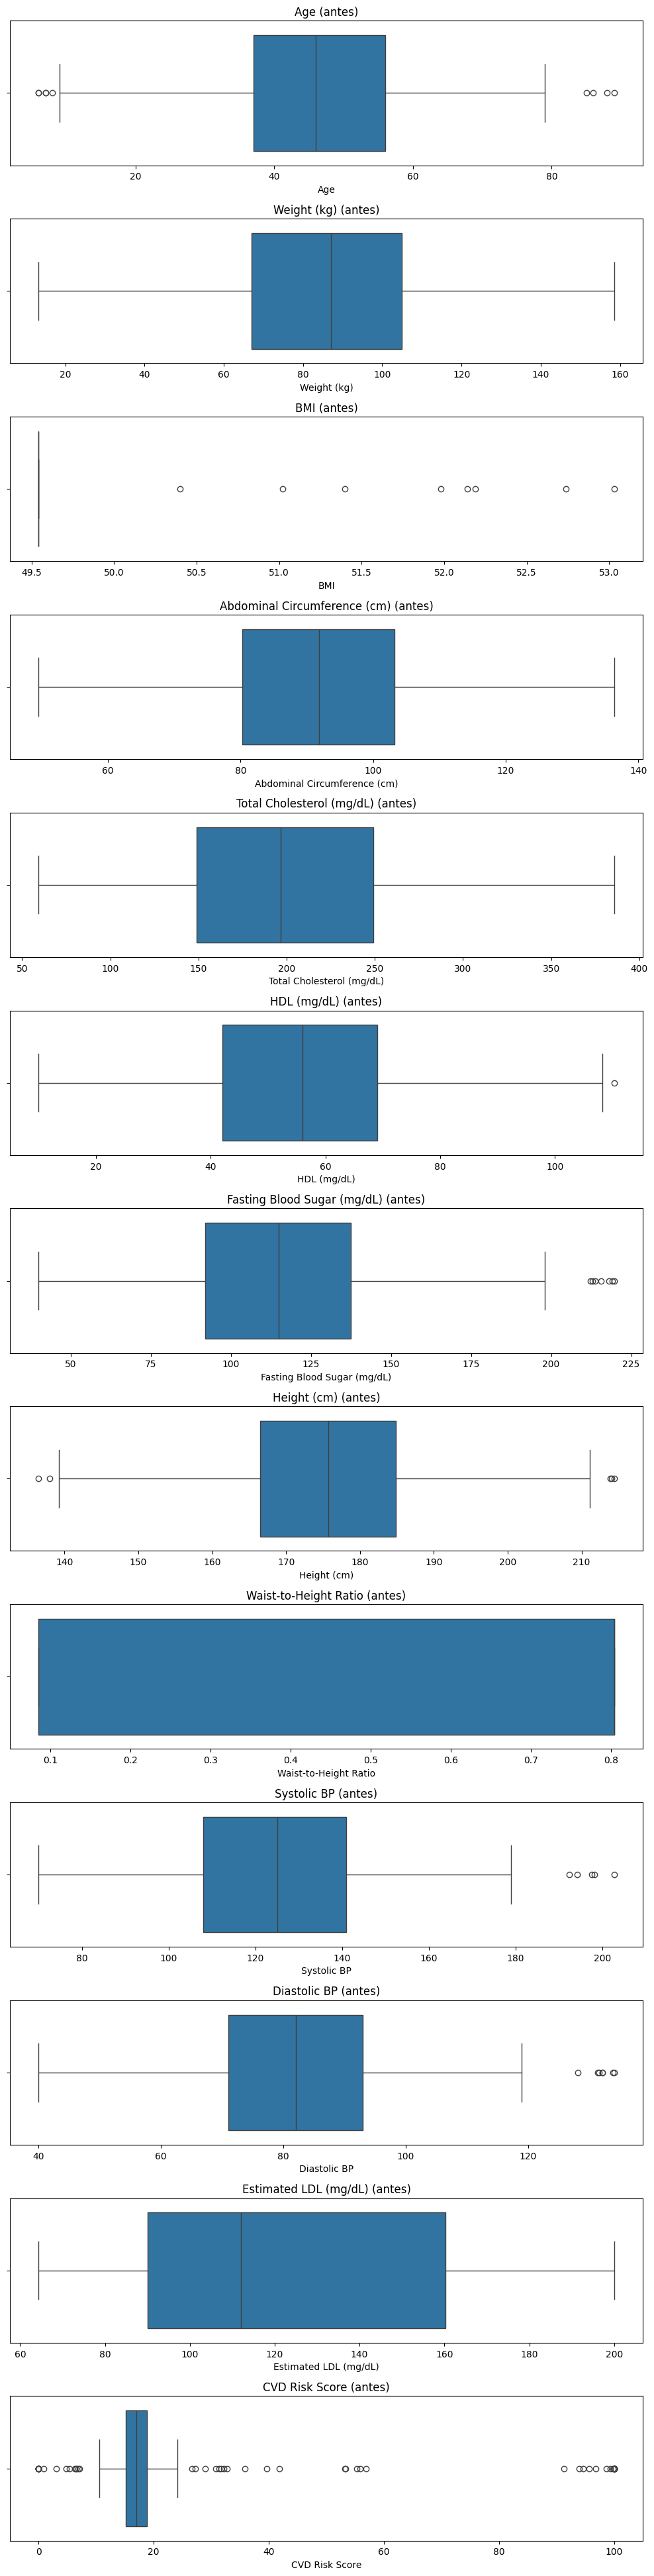


Reporte de outliers por variable:
                                      Q1        Q3         IQR      lower       upper  n_outliers
Age                            37.000000   56.0000   19.000000    8.50000   84.500000         9.0
Weight (kg)                    67.000000  105.0000   38.000000   10.00000  162.000000         0.0
BMI                            49.542000   49.5420    0.000000   49.54200   49.542000         8.0
Abdominal Circumference (cm)   80.280000  103.1800   22.900000   45.93000  137.530000         0.0
Total Cholesterol (mg/dL)     149.000000  249.0000  100.000000   -1.00000  399.000000         0.0
HDL (mg/dL)                    42.000000   69.0000   27.000000    1.50000  109.500000         1.0
Fasting Blood Sugar (mg/dL)    92.000000  137.5000   45.500000   23.75000  205.750000         7.0
Height (cm)                   166.505000  184.8405   18.335500  139.00175  212.343750         5.0
Waist-to-Height Ratio           0.085692    0.8040    0.718308   -0.99177    1.8814

In [271]:
import matplotlib.pyplot as plt

# Variables numericas sobre las que aplicar IQR
numeric_cols_iqr = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Excluir columnas auxiliares de imputación y el target
cols_excluir = ['Weight_imputed_median', 'WHR_imputed_median',
                'TC_missing_original', 'TC_imputed_median']
numeric_cols_iqr = [c for c in numeric_cols_iqr if c not in cols_excluir]

print(f"Columnas numericas para detección de outliers: {numeric_cols_iqr}")
print(f"Shape antes de eliminar outliers: {train_df.shape}")

# Boxplots ANTES de eliminar outliers
fig, axes = plt.subplots(nrows=len(numeric_cols_iqr), ncols=1,
                         figsize=(10, 3 * len(numeric_cols_iqr)))
for i, col in enumerate(numeric_cols_iqr):
    sns.boxplot(x=train_df[col], ax=axes[i])
    axes[i].set_title(f'{col} (antes)')
plt.tight_layout()
plt.show()

# Metodo IQR: eliminar filas que sean outlier en CUALQUIER variable numerica
mask = pd.Series(True, index=train_df.index)

outlier_report = {}
for col in numeric_cols_iqr:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    col_mask = train_df[col].between(lower, upper)
    # ~ es un NOT bit a bit que invierte la mascara, es decir,
    # True se vuelve False y viceversa, por lo que ~col_mask es
    # True para las filas que son outliers en esa variable
    n_outliers = (~col_mask).sum()
    outlier_report[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower': lower,
        'upper': upper,
        'n_outliers': n_outliers
    }
    # Esta linea lo que hace es que acumula la mascara global de filas a eliminar, es decir, si una fila es outlier en cualquier variable, se marcará como False en la mascara final
    mask &= col_mask

outlier_df = pd.DataFrame(outlier_report).T
print("\nReporte de outliers por variable:")
print(outlier_df.to_string())

train_df = train_df[mask].reset_index(drop=True)
print(f"\nShape después de eliminar outliers: {train_df.shape}")
print(f"Filas eliminadas: {(~mask).sum()}")

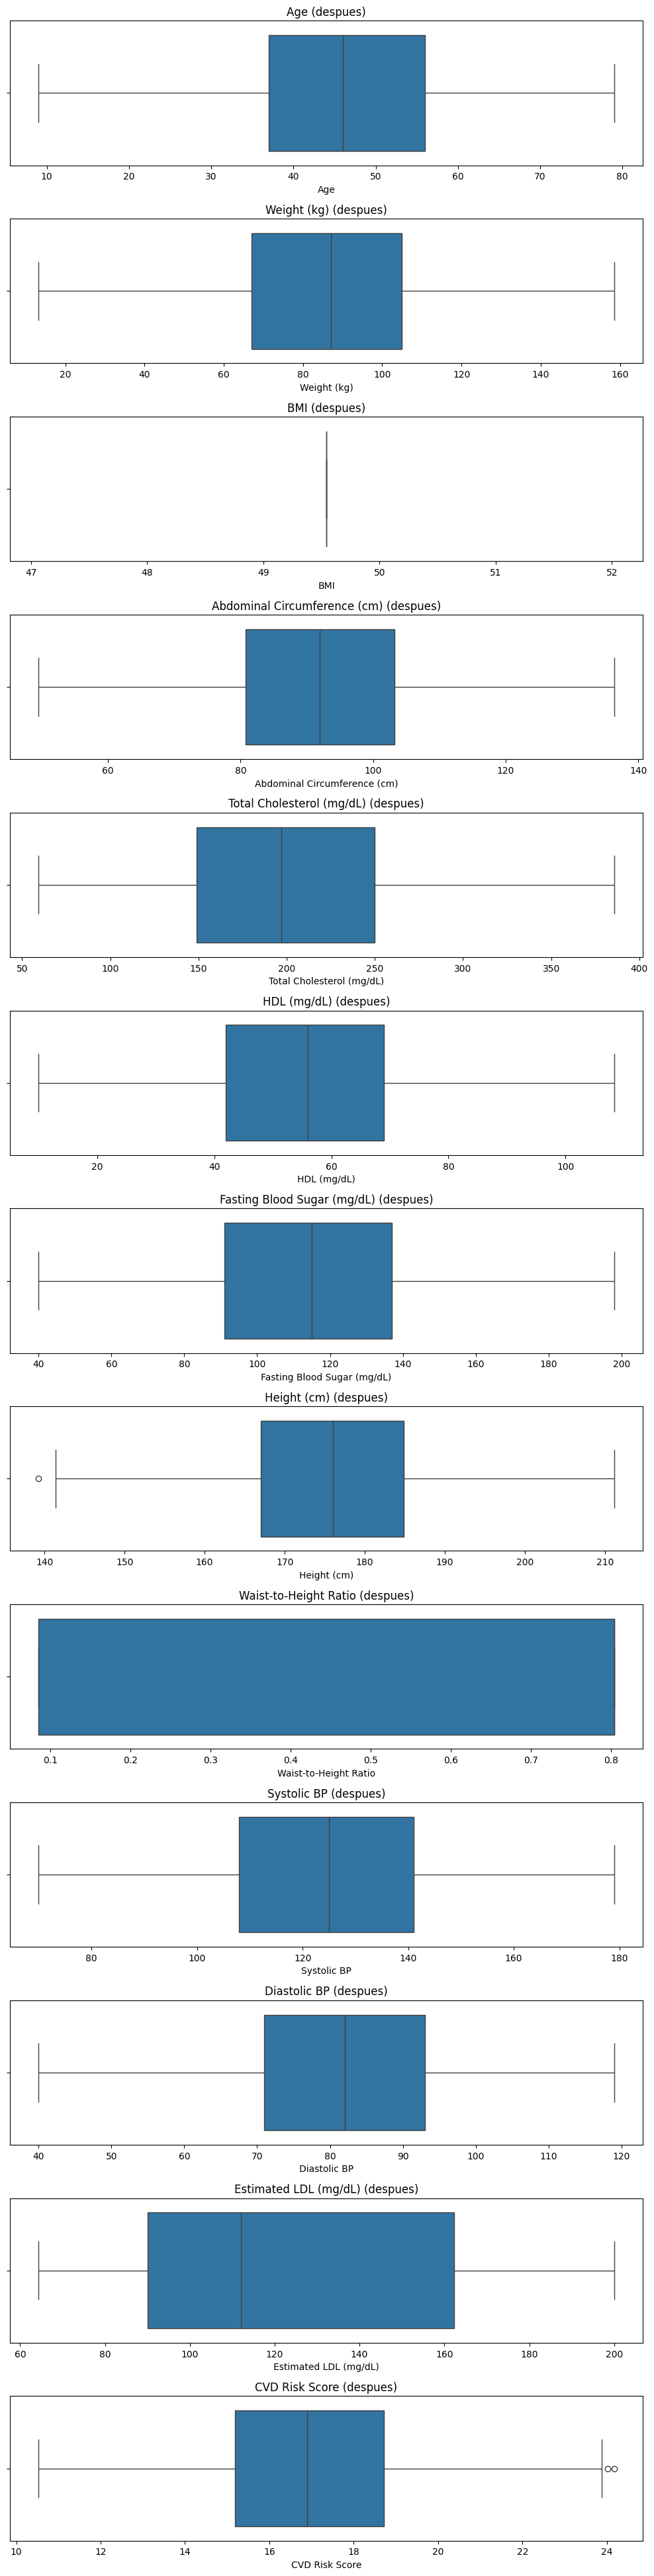

In [272]:
# Boxplots DESPUES de eliminar outliers
fig, axes = plt.subplots(nrows=len(numeric_cols_iqr), ncols=1,
                         figsize=(10, 3 * len(numeric_cols_iqr)))
for i, col in enumerate(numeric_cols_iqr):
    sns.boxplot(x=train_df[col], ax=axes[i])
    axes[i].set_title(f'{col} (despues)')
plt.tight_layout()
plt.show()

## 4. Construcción de modelos de regresión lineal
Se construyen al menos dos modelos de regresión lineal utilizando diferentes estrategias de preparación de datos y pipelines.

### Importamos las librerias necesarias

In [273]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_regression
from scipy.stats import pointbiserialr


In [274]:
# Definimos las variables a excluir del modelo
cols_to_drop = [
    'Patient ID', # El id no aporta información relevante para el modelo
    # Variables que indican si se imputó o no un valor, ya que el modelo no debería basarse en eso
    'Weight_imputed_median',
    'WHR_imputed_median',
    'TC_missing_original',
    'TC_imputed_median',
    'CVD Risk Level', # Data Leak
    'Date of Service', # No aporta información relevante para el modelo
    'Blood Pressure (mmHg)', # Redundante con Systolic BP y Diastolic BP
]

target = 'CVD Risk Score'

X = train_df.drop(columns=cols_to_drop + [target])
y = train_df[target]

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Características numéricas:", numeric_features)
print("Características categóricas:", categorical_features)


Características numéricas: ['Age', 'Weight (kg)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']
Características categóricas: ['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']


Ahora vamos a querer crear los transformers para cada tipo de variable.

Para los numeros vamos a querer escalar los datos, para esto usaremos el StandardScaler de sklearn. Esto lo hacemos para que todas las variables numéricas tengan la misma escala. Esto es importante para que el modelo de regresión lineal no le dé más importancia a una variable solo porque tiene valores más grandes.

Además el StandardScaler hace que las características tengan media 0 y desviación estándar 1. Esto se hace para bajar la condicionalidad del modelo, lo que puede ayudar a mejorar la estabilidad y la convergencia del modelo de regresion lineal.

Tener una mala condicionalidad puede hacer que el modelo sea inestable porque un pequeño cambio en los datos de entrada puede causar un gran cambio en los coeficientes del modelo.

No olvidemos que también tenemos variables categóricas, para esto usaremos el OneHotEncoder de sklearn. Esto lo que hace es convertir cada categoría en una columna binaria, lo que permite que el modelo de regresión lineal pueda interpretar la información de manera adecuada sin darle un orden específico a las categorías.

Para terminar combinamos todo en un preproccesor usando ColumnTransformer, lo que nos permite aplicar las transformaciones a cada tipo de variable.

In [275]:
# Transformador para características numéricas
# Esto lo que hace es escalar las características
# para que tengan media 0 y desviación estándar 1.


numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Transformador para características categóricas
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinamos los transformadores en un preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


Ahora dividamos el dataset en entrenamiento y prueba, para esto usaremos train_test_split de sklearn. Usaremos un 80% de los datos para entrenamiento y un 20% para prueba.

In [276]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

Ahora vamos a crear los dos modelos de regresión lineal. El primer modelo $m_1$ lo vamos a entrenar con el dataset completo, es decir, con todas las variables disponibles después de la limpieza y preparación. El segundo modelo $m_2$ solo se usaran las variables que tengan una correlación mayor a 0.04 con la variable objetivo (CVD Risk Score) para variables numericas y p-value < 0.05 para variables categóricas. Esto lo hacemos para ver si al reducir el número de variables y quedarnos solo con las más relevantes, podemos mejorar el rendimiento del modelo.

In [277]:
# Modelo 1: Usando todas las variables
model_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_1.fit(X_train, y_train)
y_pred_train_1 = model_1.predict(X_train)
y_pred_test_1 = model_1.predict(X_test)

print("Modelo 1 - Métricas de entrenamiento:")
print("MSE:", mean_squared_error(y_train, y_pred_train_1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_1)))
print("MAE:", mean_absolute_error(y_train, y_pred_train_1))
print("R²:", r2_score(y_train, y_pred_train_1))

print("\nModelo 1 - Métricas de test:")
print("MSE:", mean_squared_error(y_test, y_pred_test_1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_1)))
print("MAE:", mean_absolute_error(y_test, y_pred_test_1))
print("R²:", r2_score(y_test, y_pred_test_1))

Modelo 1 - Métricas de entrenamiento:
MSE: 1.380017877258524
RMSE: 1.1747416214889657
MAE: 0.8334435590140798
R²: 0.7745453516745098

Modelo 1 - Métricas de test:
MSE: 1.7865509709682905
RMSE: 1.3366192318563617
MAE: 0.9272074904957764
R²: 0.7322058872373411


In [278]:
# Modelo 2: Usando solo variables con correlacion > 0.5

# Trabajaremos con el dataset original sin escalar ni codificar, para calcular la correlación
train_df_2 = train.copy()

# Quitamos algunas columnas que no nos interesan

to_drop = [
    'Patient ID',
    'Date of Service',
    'Blood Pressure (mmHg)',
    'CVD Risk Level', # Data leak
]


train_df_2 = train_df_2.drop(columns=to_drop)
categorical_features_2 = train_df_2.select_dtypes(include=['object', 'category']).columns.tolist()

# Calcular la correlación solo entre variables numéricas y la variable objetivo
numeric_cols = train_df_2.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = train_df_2[numeric_cols].corr()
correlation_with_target = correlation_matrix[target].abs().sort_values(ascending=False)
print("Correlación de las variables numéricas con la variable objetivo:")
print(correlation_with_target)

Correlación de las variables numéricas con la variable objetivo:
CVD Risk Score                  1.000000
BMI                             0.133475
Systolic BP                     0.086767
Total Cholesterol (mg/dL)       0.053244
Estimated LDL (mg/dL)           0.043440
Weight (kg)                     0.042471
Diastolic BP                    0.026218
Height (cm)                     0.023800
Waist-to-Height Ratio           0.020090
Height (m)                      0.015594
HDL (mg/dL)                     0.011412
Age                             0.004056
Fasting Blood Sugar (mg/dL)     0.000947
Abdominal Circumference (cm)    0.000946
Name: CVD Risk Score, dtype: float64


In [279]:
le = LabelEncoder()

# Codificar categóricas (eliminando NaN para el cálculo)
df_temp = train_df_2[categorical_features_2 + [target]].dropna()
encoded_cats = df_temp[categorical_features_2].apply(lambda col: le.fit_transform(col.astype(str)))

# F-test (ANOVA) para medir relación con la variable objetivo
f_scores, p_values = f_regression(encoded_cats, df_temp[target])

correlation_categorical = pd.DataFrame({
    'Variable': categorical_features_2,
    'F-score': f_scores,
    'p-value': p_values
}).sort_values(by='F-score', ascending=False)

print("Correlación de las variables categóricas con la variable objetivo (ANOVA F-test):")
print(correlation_categorical.to_string(index=False))
print()

# También calcular Cramér's V / point-biserial para las binarias
print("--- Point-biserial (solo binarias) ---")
for col in categorical_features_2:
    temp = train_df_2[[col, target]].dropna()
    n_unique = temp[col].nunique()
    if n_unique == 2:
        encoded = le.fit_transform(temp[col].astype(str))
        corr, pval = pointbiserialr(encoded, temp[target])
        print(f"  {col}: r={abs(corr):.4f} (p={pval:.4f})")
    else:
        print(f"  {col}: {n_unique} categorías → usar F-test arriba")

Correlación de las variables categóricas con la variable objetivo (ANOVA F-test):
               Variable   F-score      p-value
        Diabetes Status 35.919583 2.533218e-09
Blood Pressure Category 10.412532 1.276820e-03
  Family History of CVD  2.727279 9.884249e-02
Physical Activity Level  1.409502 2.353144e-01
         Smoking Status  0.377580 5.389879e-01
                    Sex  0.060950 8.050321e-01

--- Point-biserial (solo binarias) ---
  Sex: r=0.0062 (p=0.8050)
  Smoking Status: r=0.0153 (p=0.5390)
  Diabetes Status: r=0.1478 (p=0.0000)
  Physical Activity Level: 3 categorías → usar F-test arriba
  Family History of CVD: r=0.0411 (p=0.0988)
  Blood Pressure Category: 4 categorías → usar F-test arriba


Ahora nos quedaremos con las siguientes variables para el modelo $m_2$:

**Numéricas** (correlación Pearson > 0.04 con CVD Risk Score):

| Variable | Correlación |
|---|---|
| BMI | 0.1335 |
| Systolic BP | 0.0868 |
| Total Cholesterol (mg/dL) | 0.0532 |
| Estimated LDL (mg/dL) | 0.0434 |
| Weight (kg) | 0.0425 |

**Categóricas** (p-value < 0.05 en ANOVA F-test):

| Variable | p-value |
|---|---|
| Diabetes Status | 2.53e-09 |
| Blood Pressure Category | 1.28e-03 |




In [280]:
# --- Modelo 2: Variables más relevantes ---
top_numeric_m2 = ['BMI', 'Systolic BP', 'Total Cholesterol (mg/dL)', 'Estimated LDL (mg/dL)', 'Weight (kg)']
significant_cats_m2 = ['Diabetes Status', 'Blood Pressure Category']
selected_features_m2 = top_numeric_m2 + significant_cats_m2

print(f"Variables Modelo 2: {selected_features_m2}")

# Preprocessor para modelo 2
preprocessor_2 = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler())]), top_numeric_m2),
        ('cat', Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]), significant_cats_m2)
    ]
)

X_train_m2 = X_train[selected_features_m2]
X_test_m2 = X_test[selected_features_m2]

model_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('regressor', LinearRegression())
])

model_2.fit(X_train_m2, y_train)
y_pred_train_2 = model_2.predict(X_train_m2)
y_pred_test_2 = model_2.predict(X_test_m2)

print("\nModelo 2 - Métricas de entrenamiento:")
print("MSE:", mean_squared_error(y_train, y_pred_train_2))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_2)))
print("MAE:", mean_absolute_error(y_train, y_pred_train_2))
print("R²:", r2_score(y_train, y_pred_train_2))

print("\nModelo 2 - Métricas de test:")
print("MSE:", mean_squared_error(y_test, y_pred_test_2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_2)))
print("MAE:", mean_absolute_error(y_test, y_pred_test_2))
print("R²:", r2_score(y_test, y_pred_test_2))

Variables Modelo 2: ['BMI', 'Systolic BP', 'Total Cholesterol (mg/dL)', 'Estimated LDL (mg/dL)', 'Weight (kg)', 'Diabetes Status', 'Blood Pressure Category']

Modelo 2 - Métricas de entrenamiento:
MSE: 1.4799141763335413
RMSE: 1.2165172322386317
MAE: 0.8983475609353451
R²: 0.7582252116617462

Modelo 2 - Métricas de test:
MSE: 1.781847711352876
RMSE: 1.3348586859113125
MAE: 0.9668585651339612
R²: 0.7329108798495139


## 4. Evaluación cuantitativa
Comparación del rendimiento de los dos mejores modelos utilizando RMSE, MAE y R².

## 5. Evaluación cualitativa
Análisis de los coeficientes del mejor modelo y validación de los supuestos de la regresión lineal.

## 6. Análisis de resultados
Responder aquí las preguntas planteadas en el enunciado del laboratorio.

## 7. Uso del modelo
Generación de predicciones sobre los datos de prueba no etiquetados y exportación a CSV.

In [281]:
# Cargar datos de test
# test_df = pd.read_csv('Datos Test Lab 1.csv')
# preds = pipeline_lr.predict(test_df)
# test_df['CVD Risk Score'] = preds
# test_df.to_csv('Predicciones Lab 1.csv', index=False)

## 8. Uso de herramientas de IA generativa

**Herramienta utilizada:**

**Tipo de uso:**

**Prompts utilizados:**

**Análisis crítico del resultado:**

**Aportes propios del estudiante:**